In [ ]:
import numpy as np
import pandas as pd

np.random.seed(42)#ca sa reproducem experimentul
n_samples = 1000

varsta = np.random.randint(18, 75, size=n_samples)
venit_anual = np.random.normal(55000, 20000, size=n_samples).astype(int)
scor_credit = np.random.randint(300, 850, size=n_samples)
istoric_bancar = np.random.choice(
    ["Bun", "Mediu", "Rau", None], size=n_samples, p=[0.5, 0.3, 0.1, 0.1]
)

df = pd.DataFrame(
    {
        "Varsta": varsta,
        "Venit_Anual": venit_anual,
        "Scor_Credit": scor_credit,
        "Istoric_Bancar": istoric_bancar,
    }
)
#simulam greseli in baza de date
df.loc[df.sample(frac=0.05).index, "Venit_Anual"] = (np.nan) 
df.loc[df.sample(frac=0.08).index, "Scor_Credit"] = ( np.nan)
df.loc[5, "Venit_Anual"] = -15000
df.loc[50, "Venit_Anual"] = 2500000
df.loc[100, "Varsta"] = 150
df["Scor_Credit"] = df["Scor_Credit"].astype(str)
#probabilitatea ca un client sa aiba probleme financiare-reg log
prob = 1 / (
    1
    + np.exp(
        -(
            0.02 * (500 - pd.to_numeric(df["Scor_Credit"], errors="coerce"))
            + 0.00001 * (60000 - pd.to_numeric(df["Venit_Anual"], errors="coerce"))
        )
    )
)
prob = np.nan_to_num(prob, nan=0.5)#inlocuim valorile nan cu prob neutra 0.5
df["Target_Default"] = np.random.binomial(1, prob)#1->dam cu banul o singura data pt fiecare client-distr. Bernoulli

#  Introducem  DATA LEAKAGE
df["Suma_Pierduta_Incasata"] = df["Target_Default"] * np.random.uniform( 1000, 50000, size=n_samples)
df.loc[df["Target_Default"] == 0, "Suma_Pierduta_Incasata"] = 0
#for i in range(len(df)): 
    #if df.loc[i, "Target_Default"] == 0:
      #  df.loc[i, "Suma_Pierduta"] = 0
#echivalentul la linia de mai sus doar ca avem filtrare booleană care e mult mai rapida 
#nu ar fi fost eficient cu for loop clasic pt o baza de date
df = pd.concat([df, df.iloc[[10, 20, 30]]], ignore_index=True)

print(f"Setul de date a fost generat cu succes! Formă inițială: {df.shape}")

Setul de date a fost generat cu succes! Formă inițială: (1003, 6)


In [ ]:

print(df.head())

print(df.info())

print(f"Număr duplicate: {df.duplicated().sum()}")

   Varsta  Venit_Anual Scor_Credit Istoric_Bancar  Target_Default  \
0      56      13651.0       502.0            Bun               1   
1      69          NaN       555.0            NaN               1   
2      46          NaN       534.0            NaN               0   
3      32      68393.0       644.0            Bun               0   
4      60      62331.0       833.0          Mediu               0   

   Suma_Pierduta_Incasata  
0             8517.231237  
1            18961.008182  
2                0.000000  
3                0.000000  
4                0.000000  
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 1003 entries, 0 to 1002
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Varsta                  1003 non-null   int32  
 1   Venit_Anual             953 non-null    float64
 2   Scor_Credit             923 non-null    str    
 3   I

In [17]:
#facem o filtrare initiala
df = df.drop_duplicates()
df["Scor_Credit"] = pd.to_numeric(df["Scor_Credit"], errors="coerce")

print(f"Forma setului de date după eliminarea duplicatelor: {df.shape}")
print(df.dtypes)

Forma setului de date după eliminarea duplicatelor: (1000, 6)
Varsta                      int32
Venit_Anual               float64
Scor_Credit               float64
Istoric_Bancar                str
Target_Default              int32
Suma_Pierduta_Incasata    float64
dtype: object


In [18]:
#metoda1
mediana_venit = df["Venit_Anual"].median()
df["Venit_Anual"] = df["Venit_Anual"].fillna(mediana_venit)#ne ocupam de valorila nan
#metoda2
modul_istoric = df["Istoric_Bancar"].mode()[0]#vedem care este termenul cel mai des intalnit de pe o linie si il extragem cu [0] pt altfel ar returna o lista
df["Istoric_Bancar"] = df["Istoric_Bancar"].fillna(modul_istoric)
print("Valori lipsă rămase după primele 2 metode:")
print(df.isnull().sum())

Valori lipsă rămase după primele 2 metode:
Varsta                     0
Venit_Anual                0
Scor_Credit               80
Istoric_Bancar             0
Target_Default             0
Suma_Pierduta_Incasata     0
dtype: int64


In [19]:
#metoda 3
#grupam dupa istoricul bancar(groupby("Istoric_bancar")), iar la valorile lipsa(fillna) inlocuim cu media clientilor din acel istoric bancar(["Scor_credit"].transform("mean"))
df["Scor_Credit"]=df["Scor_Credit"].fillna(df.groupby("Istoric_Bancar")["Scor_Credit"].transform("mean"))

print("Verificare finală valori lipsă:")
print(df.isnull().sum())

Verificare finală valori lipsă:
Varsta                    0
Venit_Anual               0
Scor_Credit               0
Istoric_Bancar            0
Target_Default            0
Suma_Pierduta_Incasata    0
dtype: int64


In [20]:
def detecteaza_outliers_iqr(data_frame, coloana):
    Q1 = data_frame[coloana].quantile(0.25)
    Q3 = data_frame[coloana].quantile(0.75)
    IQR = Q3 - Q1

    limita_inferioara = Q1 - 1.5 * IQR
    limita_superioara = Q3 + 1.5 * IQR

  
    outliers = data_frame[
        (data_frame[coloana] < limita_inferioara)
        | (data_frame[coloana] > limita_superioara)
    ]
    return outliers, limita_inferioara, limita_superioara


# Testam functia
outliers_venit, lim_inf, lim_sup = detecteaza_outliers_iqr(df, "Venit_Anual")
print(
    f"Pentru Venit_Anual, limitele normale sunt: [{lim_inf:.2f}, {lim_sup:.2f}]"
)
print(f"Am detectat {len(outliers_venit)} outliers în coloana Venit_Anual.")
print("\nCâteva exemple de outliers găsiți:")
print(outliers_venit[["Varsta", "Venit_Anual"]].head())

Pentru Venit_Anual, limitele normale sunt: [7022.00, 104242.00]
Am detectat 18 outliers în coloana Venit_Anual.

Câteva exemple de outliers găsiți:
     Varsta  Venit_Anual
5        25     -15000.0
36       33     116577.0
50       56    2500000.0
102      41       5567.0
204      42       1062.0


In [21]:

df["Venit_Anual"] = np.clip(df["Venit_Anual"], lim_inf, lim_sup)
outliers_varsta, lim_inf_v, lim_sup_v = detecteaza_outliers_iqr(df, "Varsta")
df["Varsta"] = np.clip(df["Varsta"], lim_inf_v, lim_sup_v)
print("Outliers au fost plafonați cu succes!")
print(df.describe())  

Outliers au fost plafonați cu succes!
            Varsta    Venit_Anual  Scor_Credit  Target_Default  \
count  1000.000000    1000.000000  1000.000000     1000.000000   
mean     46.284125   55949.613000   576.058093        0.387000   
std      16.370676   19289.571039   152.812534        0.487307   
min      18.000000    7022.000000   300.000000        0.000000   
25%      33.000000   43479.500000   453.000000        0.000000   
50%      46.000000   55902.000000   577.000000        0.000000   
75%      60.250000   67784.500000   705.000000        1.000000   
max     101.125000  104242.000000   849.000000        1.000000   

       Suma_Pierduta_Incasata  
count             1000.000000  
mean              9876.934762  
std              15248.034122  
min                  0.000000  
25%                  0.000000  
50%                  0.000000  
75%              18542.977341  
max              49929.479523  


C:\Users\User1\AppData\Local\Temp\ipykernel_20292\2384204363.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


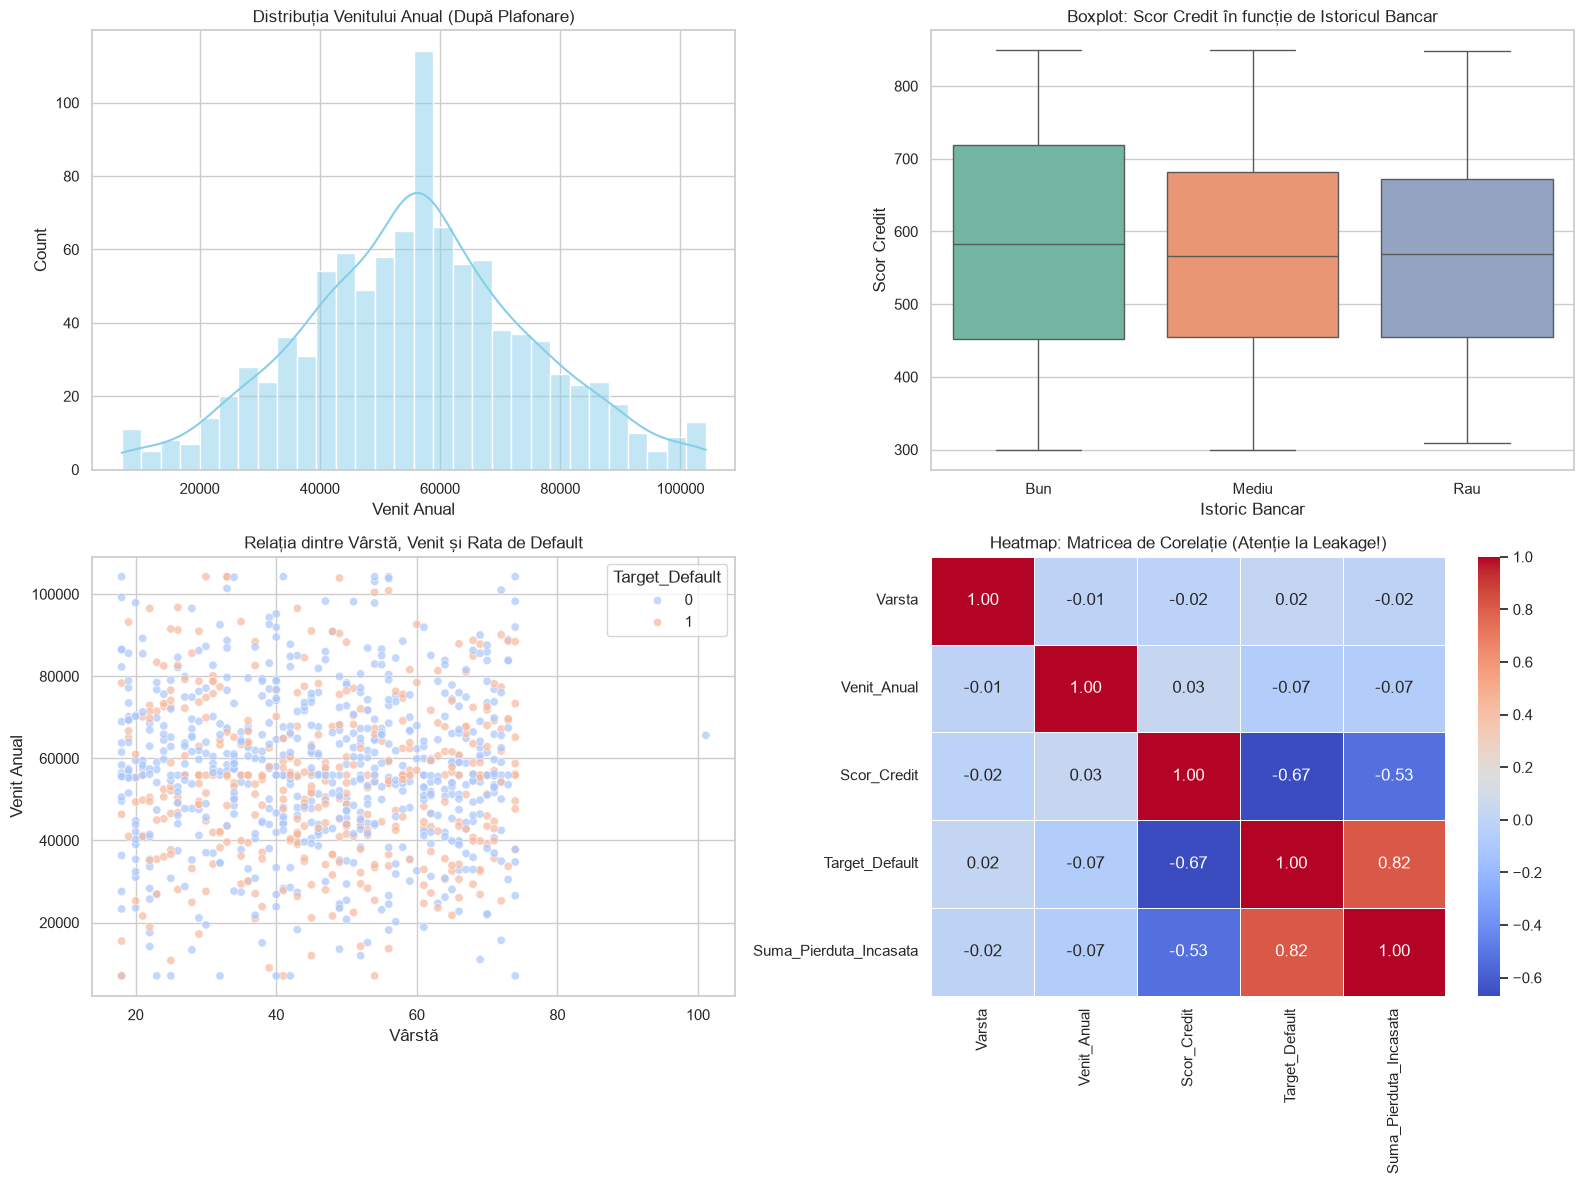

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# stilul graficelor
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.histplot(
    df["Venit_Anual"], kde=True, ax=axes[0, 0], color="skyblue", bins=30
)
axes[0, 0].set_title("Distribuția Venitului Anual (După Plafonare)")
axes[0, 0].set_xlabel("Venit Anual")

sns.boxplot(
    x="Istoric_Bancar", y="Scor_Credit", data=df, ax=axes[0, 1], palette="Set2"
)
axes[0, 1].set_title("Boxplot: Scor Credit în funcție de Istoricul Bancar")
axes[0, 1].set_xlabel("Istoric Bancar")
axes[0, 1].set_ylabel("Scor Credit")


sns.scatterplot(
    x="Varsta",
    y="Venit_Anual",
    hue="Target_Default",
    data=df,
    ax=axes[1, 0],
    palette="coolwarm",
    alpha=0.7,
)
axes[1, 0].set_title("Relația dintre Vârstă, Venit și Rata de Default")
axes[1, 0].set_xlabel("Vârstă")
axes[1, 0].set_ylabel("Venit Anual")


num_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[num_cols].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    ax=axes[1, 1],
)
axes[1, 1].set_title("Heatmap: Matricea de Corelație (Atenție la Leakage!)")


plt.tight_layout()
plt.show()

In [ ]:

df = df.drop(columns=["Suma_Pierduta_Incasata"])
df["Raport_Venit_Varsta"] = df["Venit_Anual"] / df["Varsta"]

# Feature 2: scor credit ponderat cu venitul
df["Scor_Ponderat_Venit"] = df["Scor_Credit"] * (df["Venit_Anual"] / 100000)

# Feature 3: Indicator de risc crescut
df["Risc_Tinar_Scor_Mic"] = (
    ((df["Varsta"] < 35) & (df["Scor_Credit"] < 500)).astype(int)
)
istoric_mapping = {"Rau": 0, "Mediu": 1, "Bun": 2}
df["Istoric_Bancar_Encoded"] = df["Istoric_Bancar"].map(istoric_mapping)

# acum avem varianta encodata nu mai trb cea originala
df = df.drop(columns=["Istoric_Bancar"])

cols_to_normalize = [
    "Varsta",
    "Venit_Anual",
    "Scor_Credit",
    "Raport_Venit_Varsta",
    "Scor_Ponderat_Venit",
]

for col in cols_to_normalize:
    col_min = df[col].min()
    col_max = df[col].max()
    df[col + "_Normalized"] = (df[col] - col_min) / (col_max - col_min)

# Eliminăm coloanele vechi non-normalizate 
df_final = df.drop(columns=cols_to_normalize)
print("Feature Engineering complet!")
print(df_final.head())

Feature Engineering complet!
   Target_Default  Risc_Tinar_Scor_Mic  Istoric_Bancar_Encoded  \
0               1                    0                       2   
1               1                    0                       2   
2               0                    0                       2   
3               0                    0                       2   
4               0                    0                       1   

   Varsta_Normalized  Venit_Anual_Normalized  Scor_Credit_Normalized  \
0           0.457143                0.068186                0.367942   
1           0.613534                0.502777                0.464481   
2           0.336842                0.502777                0.426230   
3           0.168421                0.631259                0.626594   
4           0.505263                0.568906                0.970856   

   Raport_Venit_Varsta_Normalized  Scor_Ponderat_Venit_Normalized  
0                        0.026135                        0.043267  
1    

In [13]:

df_final.to_csv("credit_risk_cleaned.csv", index=False)
print("Datasetul curățat a fost salvat cu succes sub numele 'credit_risk_cleaned.csv'!")

Datasetul curățat a fost salvat cu succes sub numele 'credit_risk_cleaned.csv'!
